In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score)

In [10]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [11]:
path = "/content/gdrive/MyDrive/MachineLearning/praktikum/prak10/"

In [12]:
df = pd.read_csv(path + "/data/weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [14]:
print("=== DATASET AWAL ===")
display(df.head())
print("\nJumlah Baris dan Kolom:", df.shape)

=== DATASET AWAL ===


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy



Jumlah Baris dan Kolom: (13200, 11)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [16]:
print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())


=== CEK MISSING VALUE ===
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64


In [17]:
#cek tipe data
print("\n=== TIPE DATA ===")
print(df.dtypes)


=== TIPE DATA ===
Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object


In [18]:
categorical_cols = ['Cloud Cover', 'Season', 'Location', 'Weather Type']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\n=== DATASET SETELAH ENCODING ===")
display(df.head())


=== DATASET SETELAH ENCODING ===


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


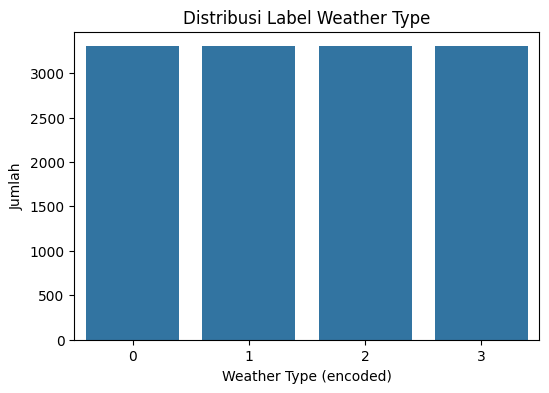

In [19]:
#distribusi
plt.figure(figsize=(6,4))
sns.countplot(x=df['Weather Type'])
plt.title("Distribusi Label Weather Type")
plt.xlabel("Weather Type (encoded)")
plt.ylabel("Jumlah")
plt.show()

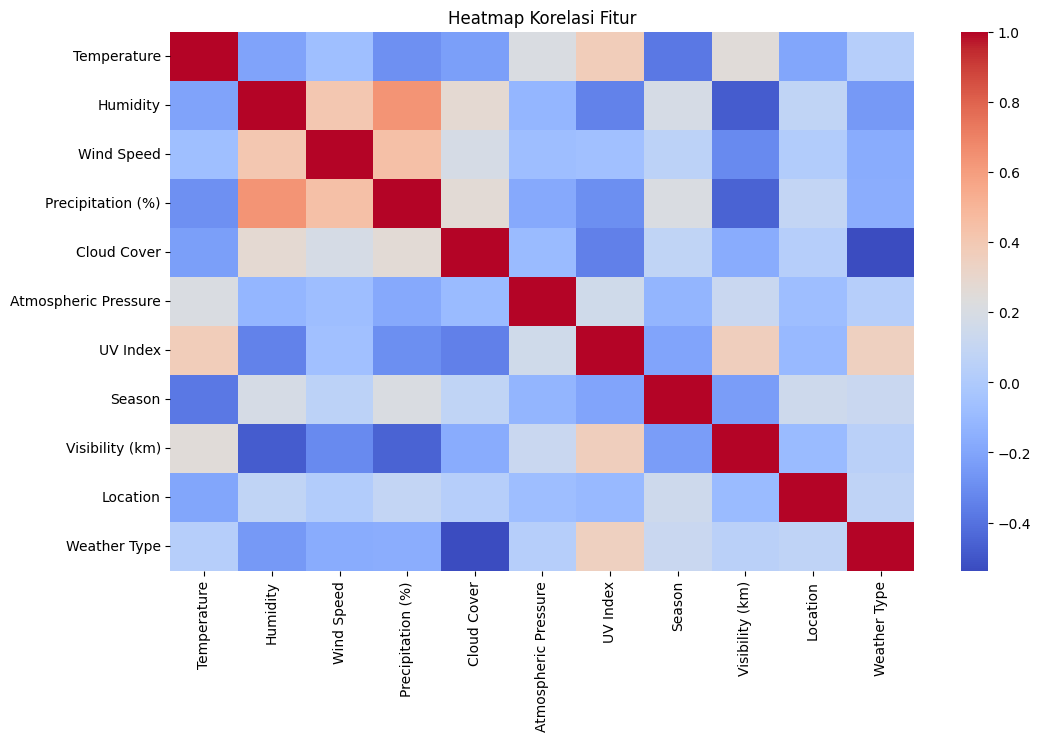

In [20]:
#heatmap
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur")
plt.show()

In [21]:
#split data fitur
X = df.drop(columns=['Weather Type'])
y = df['Weather Type']

# Scaling (agar model lebih stabil)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

In [22]:
#train model naive bayes
nb = GaussianNB()
nb.fit(x_train, y_train)

GaussianNB()

In [23]:
# Prediksi
y_pred = nb.predict(x_test)


=== CONFUSION MATRIX ===
[[628  99  11  59]
 [ 23 699  52  48]
 [  9   8 806  42]
 [ 64  34  13 705]]


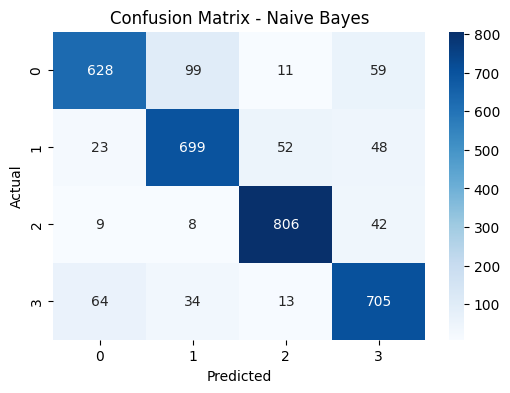

In [24]:
# 9. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# 10. METRIK PERFORMANCE
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')

print("\n=== PERFORMANCE METRICS ===")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)


=== PERFORMANCE METRICS ===
Accuracy : 0.86
Precision: 0.8597263259226947
Recall   : 0.8585205724670499


In [28]:
# PREDIKSI CUACA BARU
sample = [[25, 70, 10, 50, 1, 1010, 5, 1, 5, 1]]
sample_scaled = scaler.transform(sample)

predicted = nb.predict(sample_scaled)
print("\nPrediksi Sample Baru (encoded):", predicted[0])


Prediksi Sample Baru (encoded): 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
